# Milestone 2
**Project Number:** Canvas Project #77   
**Group Members:** Emily Chen, Cindy Ren, Alice Wang     

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
import tarfile
import os
import glob
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import numpy as np
import time
import tempfile
import shutil
import pandas as pd
from pathlib import Path
from torch.utils.data import random_split
import random

## 1. Problem Statement

Vision Transformers (ViTs) have emerged as a strong alternative to Convolutional Neural Networks (CNNs) for image classification. However, most comparisons between these architectures are conducted on natural image datasets (e.g., ImageNet), where textures, lighting, and object variability follow real-world distributions. It remains unclear whether these findings generalize to structured, non-natural visual environments.

Minecraft provides a controlled and highly structured visual domain characterized by consistent rendering rules, repetitive textures, and strong spatial regularity. These properties make it an ideal testbed to examine how different model architectures learn visual representations under non-natural conditions.

In this project, we investigate whether a ViT can outperform a traditional CNN on Minecraft block classification using the MiDaS-60 dataset (36,000 images across 60 block classes). Beyond standard performance metrics, we analyze model interpretability using Attention Rollout (for ViT) and Grad-CAM (for CNN) to compare the visual features each model relies on. This allows us to assess whether ViTs capture more global context while CNNs focus on local patterns, or whether the structured nature of Minecraft reduces this distinction.

###  Research Question

Can a Vision Transformer outperform a Convolutional Neural Network for Minecraft block classification, and do interpretability methods (Attention Rollout vs. Grad-CAM) reveal meaningful differences in the visual representations learned by the two architectures in a non-natural image domain?

## 2. Dataset Description

We use the MiDaS (Minecraft Dataset for Non-Natural Image Benchmarking) dataset, which contains approximately 36,000 labeled Minecraft images spanning 60 block classes. The dataset also includes metadata such as biome type and time of day, providing additional contextual information.

The dataset is publicly available through the MiDaS repository and OSF hosting:
https://github.com/MinecraftDataset/MiDaS/tree/main.

Two versions of the dataset are provided:

- MiDaS_small: lower-resolution images
- MiDaS_large: higher-resolution images

Both versions contain the same scenes at different resolutions. In this project, we will primarily use [specify which one once finalized] for model training and evaluation.

__Note on data access:__
The dataset is distributed in multiple .tar files (~4.3GB total). During download and extraction, incomplete file concatenation may lead to a reduced size (~4.0GB), indicating missing segments. This issue is documented and may require alternative download or verification methods (e.g., checksum validation or re-downloading specific parts).

## 3. EDA

### 3.1 Dataset Overview
We first perform an exploratory analysis to understand the structure and composition of the dataset. The dataset consists of 60 block classes, with 600 images per class, indicating a well-balanced distribution across categories. A predefined train/test split (90/10) is provided, resulting in 540 training images and 60 testing images per class. This balanced setup ensures that model performance is not biased by class imbalance and allows for fair comparison across classes.

In [3]:
# DATA_ROOT = '/content/drive/MyDrive/MiDaS'
DATA_ROOT = 'data/'
SMALL_DIR = os.path.join(DATA_ROOT, 'MiDaS-60_small')
LARGE_DIR = os.path.join(DATA_ROOT, 'MiDaS-60_large')

In [4]:
# load dataset
def load_data(data_path, transform=None):
    """
    Load MiDaS-60 dataset and return datasets only (no loaders).
    """
    train_path = os.path.join(data_path, 'train')
    test_path  = os.path.join(data_path, 'test')

    assert os.path.exists(train_path), f"Train folder not found: {train_path}"
    assert os.path.exists(test_path),  f"Test folder not found:  {test_path}"

    transform = transform if transform is not None else transforms.ToTensor()

    train_dataset = datasets.ImageFolder(train_path, transform=transform)
    test_dataset  = datasets.ImageFolder(test_path,  transform=transform)

    print(f"Loaded {len(train_dataset)} train / {len(test_dataset)} test images "
          f"across {len(train_dataset.classes)} classes")

    return train_dataset, test_dataset

# display class distribution and totals
def print_dataset_statistics(train_dataset, test_dataset, label=''):
    """Print per-class train counts and global totals."""
    idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}
    train_counts = Counter(label_idx for _, label_idx in train_dataset.samples)

    header = f"  {label}  " if label else ""
    print("=" * 50)
    print(f"{header + 'CLASS-WISE COUNTS (Train)':^50}")
    print("=" * 50)
    print(f"  {'Class':<28} {'# Images':>10}")
    print("-" * 50)
    for idx, count in sorted(train_counts.items(), key=lambda x: idx_to_class[x[0]]):
        print(f"  {idx_to_class[idx]:<28} {count:>10}")
    print("=" * 50)
    print(f"  Total train images : {len(train_dataset):>6}")
    print(f"  Total test  images : {len(test_dataset):>6}")
    print(f"  Total overall      : {len(train_dataset)+len(test_dataset):>6}")
    print(f"  Number of classes  : {len(train_dataset.classes):>6}")
    print("=" * 50)

In [5]:
# Small dataset
train_ds_s, test_ds_s = load_data(SMALL_DIR)
print_dataset_statistics(train_ds_s, test_ds_s, label='SMALL')

Loaded 32400 train / 3600 test images across 60 classes
          SMALL  CLASS-WISE COUNTS (Train)        
  Class                          # Images
--------------------------------------------------
  acacia_log                          540
  acacia_planks                       540
  bed                                 540
  birch_log                           540
  birch_planks                        540
  bookshelf                           540
  bricks                              540
  chest                               540
  clay                                540
  coal_ore                            540
  cobblestone                         540
  crafting_table                      540
  crimson_planks                      540
  dark_oak_log                        540
  dark_oak_planks                     540
  diamond_ore                         540
  diorite                             540
  dirt                                540
  dirt_path                           540
  

In [6]:
def plot_class_distribution(train_dataset, test_dataset, title_prefix=''):
    idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}
    classes      = sorted(train_dataset.classes)
    train_counts = Counter(label for _, label in train_dataset.samples)
    test_counts  = Counter(label for _, label in test_dataset.samples)

    train_vals = [train_counts[train_dataset.class_to_idx[c]] for c in classes]
    test_vals  = [test_counts [test_dataset.class_to_idx[c]]  for c in classes]
    total_train = sum(train_vals)
    total_test  = sum(test_vals)

    fig = plt.figure(figsize=(14, 5))
    fig.suptitle(f'{title_prefix} — Class Distribution Summary', fontsize=13, y=1.02)
    gs  = fig.add_gridspec(1, 2, width_ratios=[1, 2.5], wspace=0.35)

    # ── Left: donut chart showing overall train/test split ────────────────────
    ax_donut = fig.add_subplot(gs[0])
    wedges, texts, autotexts = ax_donut.pie(
        [total_train, total_test],
        labels=['Train', 'Test'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['#4C9BE8', '#F28C38'],
        wedgeprops=dict(width=0.5),          # donut hole
        textprops=dict(fontsize=11),
    )
    for at in autotexts:
        at.set_fontsize(11)
        at.set_fontweight('bold')
        at.set_color('white')
    ax_donut.set_title(
        f'Overall Split\n{total_train:,} train  /  {total_test:,} test',
        fontsize=10, pad=12
    )

    # ── Right: per-class count as a dot strip (one dot per class) ────────────
    ax_dot = fig.add_subplot(gs[1])
    x = range(len(classes))

    ax_dot.scatter(x, train_vals, color='#4C9BE8', s=40, label='Train', zorder=3, alpha=0.85)
    ax_dot.scatter(x, test_vals,  color='#F28C38', s=40, label='Test',  zorder=3, alpha=0.85)

    # Shade the uniform bands so the eye immediately sees "all the same"
    ax_dot.axhline(train_vals[0], color='#4C9BE8', linewidth=1,   linestyle='--', alpha=0.4)
    ax_dot.axhline(test_vals[0],  color='#F28C38', linewidth=1,   linestyle='--', alpha=0.4)
    ax_dot.fill_between(x, train_vals[0]-5, train_vals[0]+5, color='#4C9BE8', alpha=0.08)
    ax_dot.fill_between(x, test_vals[0]-5,  test_vals[0]+5,  color='#F28C38', alpha=0.08)

    # Annotate the uniform value once on the right
    ax_dot.annotate(f'{train_vals[0]} / class', xy=(len(classes)-1, train_vals[0]),
                    xytext=(8, 0), textcoords='offset points',
                    va='center', fontsize=9, color='#4C9BE8')
    ax_dot.annotate(f'{test_vals[0]} / class',  xy=(len(classes)-1, test_vals[0]),
                    xytext=(8, 0), textcoords='offset points',
                    va='center', fontsize=9, color='#F28C38')

    ax_dot.set_xticks(list(x))
    ax_dot.set_xticklabels(classes, rotation=90, fontsize=6.5)
    ax_dot.set_ylabel('Images per Class')
    ax_dot.set_title(f'Per-Class Counts  ({len(classes)} classes — perfectly balanced)', fontsize=10)
    ax_dot.set_ylim(0, max(train_vals) * 1.2)
    ax_dot.legend(fontsize=9)
    ax_dot.spines[['top', 'right']].set_visible(False)
    ax_dot.margins(x=0.02)

    plt.tight_layout()
    plt.show()

/var/folders/ts/ggq2pftx0wq1q2l8zxfg6r_m0000gn/T/ipykernel_13662/473733556.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


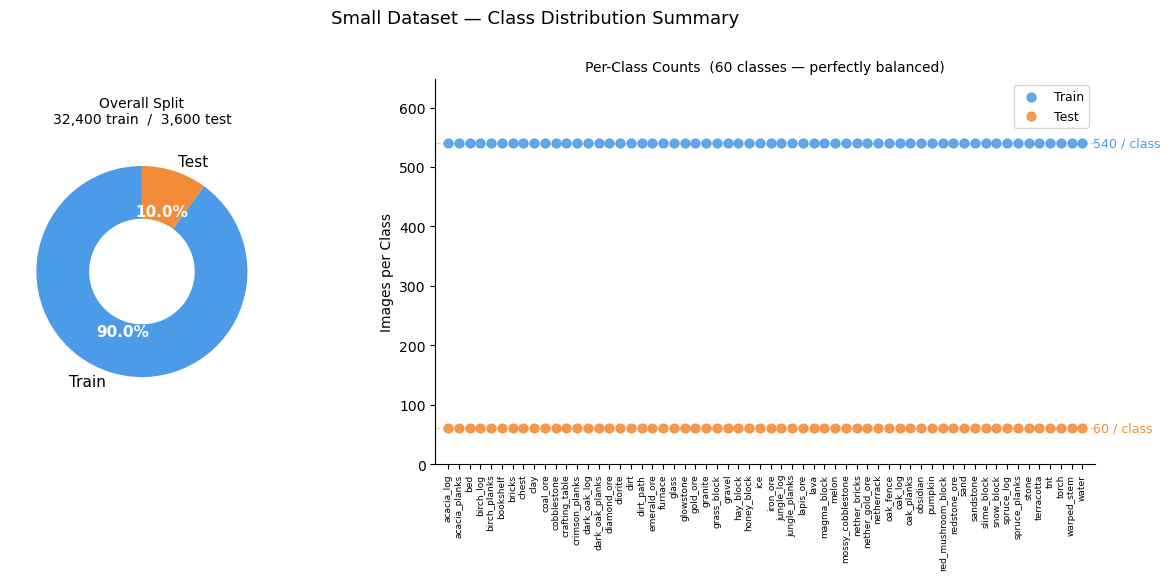

In [7]:
plot_class_distribution(train_ds_s, test_ds_s,  title_prefix='Small Dataset')

### 3.2 Visual Inspection of Samples
To gain an intuitive understanding of the data, we visualize representative samples from each class. Several consistent patterns emerge from this inspection. Many images share common background elements, such as grass blocks, sky, and forest-like environments, which likely reflect similar biome settings within the game.

In addition, images are captured under varying lighting conditions (e.g., daytime versus nighttime), introducing global differences in brightness across samples. Despite these variations in background and illumination, intra-class visual patterns remain highly consistent. Most block classes are characterized by repetitive textures and strong geometric structures, reflecting the grid-based nature of Minecraft.

These observations suggest that while global context (background and lighting) varies, the defining characteristics of each class are primarily driven by local texture and structural patterns.

In [8]:
# dispaly example images for each class
def show_class_samples(train_dataset, samples_per_class=4, title_prefix=''):
    """Display a grid of raw PIL images — one row per class."""
    idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}
    class_samples = {}
    for path, label in train_dataset.samples:
        cls = idx_to_class[label]
        class_samples.setdefault(cls, []).append(path)

    classes   = sorted(class_samples.keys())
    n_classes = len(classes)

    fig, axes = plt.subplots(
        n_classes, samples_per_class,
        figsize=(samples_per_class*2, n_classes*1)
    )
    fig.suptitle(
        f"{title_prefix} — Sample Images per Class (Train, No Transform)",
        fontsize=12, y=1.01
    )

    for row, cls in enumerate(classes):
        paths = class_samples[cls][:samples_per_class]
        for col in range(samples_per_class):
            ax = axes[row, col] if n_classes > 1 else axes[col]
            if col < len(paths):
                ax.imshow(Image.open(paths[col]).convert('RGB'))
            else:
                ax.set_facecolor('#1a1a1a')
            ax.set_xticks([]); ax.set_yticks([])
            if col == 0:
                ax.set_ylabel(cls, fontsize=8, rotation=0, labelpad=70, va='center')

    plt.tight_layout()
    plt.show()

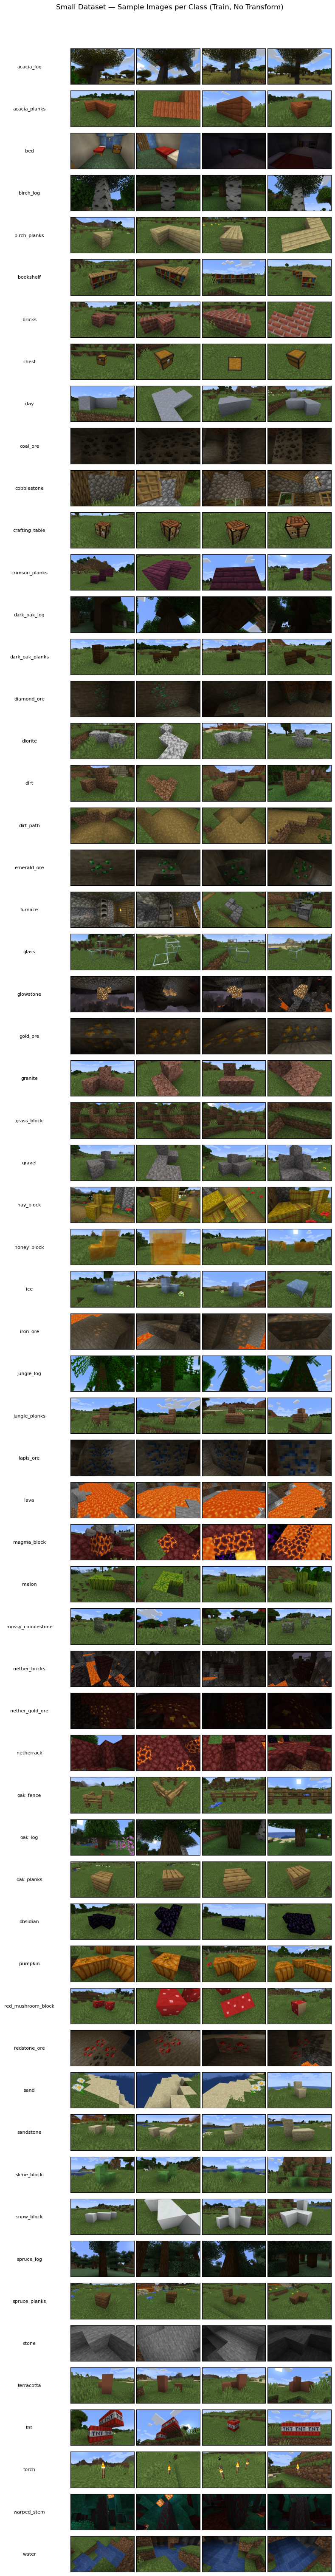

In [9]:
show_class_samples(train_ds_s, samples_per_class=4, title_prefix='Small Dataset')

### 3.3 Metadata Analysis

We link the provided metadata to each image to analyze the distribution of environmental factors in the dataset. Our exploratory analysis shows that both biome and time of day are unevenly distributed, introducing variability in background context and lighting conditions.

As illustrated below (first figure), a small number of biomes (e.g., savanna, jungle, and forest-related environments) dominate the dataset, while others are underrepresented. In addition, the distribution of day and night conditions varies across biomes, indicating that lighting is not independent of environmental context.

Further, as shown in the second figure below, individual block classes appear across multiple biomes, but with noticeable biases toward certain environments. This suggests that background context is correlated with object classes, which may encourage models to rely on spurious environmental cues rather than intrinsic object features.

Together, these observations indicate that biome classification is largely driven by global scene characteristics and is influenced by both class-dependent context and lighting conditions. In contrast, block classification requires distinguishing fine-grained visual patterns that are robust to such variations, making it a more suitable task for comparing CNNs and Vision Transformers.

To mitigate the influence of lighting differences (e.g., day vs. night), we will apply standard image normalization, which reduces global intensity variation and encourages models to focus on discriminative visual features.

In [10]:
def build_image_df(root_dir):
    rows = []
    root = Path(root_dir)

    for split in ["train", "test"]:
        split_dir = root / split
        if not split_dir.exists():
            continue

        class_names = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
        class_to_idx = {cls: i for i, cls in enumerate(class_names)}

        for cls in class_names:
            class_dir = split_dir / cls
            for img_path in class_dir.glob("*"):
                if img_path.suffix.lower() in [".png", ".jpg", ".jpeg", ".webp"]:
                    rows.append({
                        "image_path": str(img_path),
                        "image_name": img_path.name,
                        "split": split,
                        "class_name": cls,
                        "class_idx": class_to_idx[cls]
                    })

    df_images = pd.DataFrame(rows)
    print(f"Loaded {len(df_images)} images")
    return df_images

In [11]:
df_images = build_image_df(SMALL_DIR)
df_images.head()

Loaded 36000 images


,image_path,image_name,split,class_name,class_idx
0,data/MiDaS-60_small/train/acacia_log/acacia_lo...,acacia_log_495.png,train,acacia_log,0
1,data/MiDaS-60_small/train/acacia_log/acacia_lo...,acacia_log_481.png,train,acacia_log,0
2,data/MiDaS-60_small/train/acacia_log/acacia_lo...,acacia_log_318.png,train,acacia_log,0
3,data/MiDaS-60_small/train/acacia_log/acacia_lo...,acacia_log_330.png,train,acacia_log,0
4,data/MiDaS-60_small/train/acacia_log/acacia_lo...,acacia_log_456.png,train,acacia_log,0


In [12]:
# read all class info CSVs and combine into one DataFrame
def load_class_info(class_info_dir):
    class_info_dir = Path(class_info_dir)
    dfs = []

    for csv_file in sorted(class_info_dir.glob("*.csv")):
        df = pd.read_csv(csv_file)

        # add class name from filename, e.g. "acacia_log.csv" -> "acacia_log"
        df["class_name"] = csv_file.stem

        dfs.append(df)

    df_meta = pd.concat(dfs, ignore_index=True)
    print(f"Loaded metadata from {len(dfs)} class-info files")
    print(f"Metadata shape: {df_meta.shape}")
    return df_meta

df_meta = load_class_info("data/class_info")
df_meta.head()

Loaded metadata from 60 class-info files
Metadata shape: (36000, 15)


,index,filename,block,block_namespace_id,block_details,block_natural_position,biome,biome_namespace_id,weather,dimension,dimension_namespace_id,time_ticks,time_description,version,class_name
0,0,acacia_log_000.png,acacia_log,minecraft:acacia_log,tree,True,savanna,minecraft:savanna,clear,overworld,minecraft:overworld,1000.0,day,1.17.1,acacia_log
1,1,acacia_log_001.png,acacia_log,minecraft:acacia_log,tree,True,savanna,minecraft:savanna,clear,overworld,minecraft:overworld,1000.0,day,1.17.1,acacia_log
2,2,acacia_log_002.png,acacia_log,minecraft:acacia_log,tree,True,savanna,minecraft:savanna,clear,overworld,minecraft:overworld,1000.0,day,1.17.1,acacia_log
3,3,acacia_log_003.png,acacia_log,minecraft:acacia_log,tree,True,savanna,minecraft:savanna,clear,overworld,minecraft:overworld,1000.0,day,1.17.1,acacia_log
4,4,acacia_log_004.png,acacia_log,minecraft:acacia_log,tree,True,savanna,minecraft:savanna,clear,overworld,minecraft:overworld,1000.0,day,1.17.1,acacia_log


In [13]:
def merge_metadata(df_images, df_meta):
    df_merged = df_images.merge(
        df_meta,
        left_on=["image_name", "class_name"],
        right_on=["filename", "block"],
        how="left"
    ).drop(columns=["filename", "block", "class_name_y"])
    
    df_merged = df_merged.rename(columns={"class_name_x": "class_name"})
    return df_merged

# merge the image dataframe with metadata dataframe
df = merge_metadata(df_images, df_meta)
print(f"Merged DataFrame shape: {df.shape}")
df.head()

Merged DataFrame shape: (36000, 17)


,image_path,image_name,split,class_name,class_idx,index,block_namespace_id,block_details,block_natural_position,biome,biome_namespace_id,weather,dimension,dimension_namespace_id,time_ticks,time_description,version
0,data/MiDaS-60_small/train/acacia_log/acacia_lo...,acacia_log_495.png,train,acacia_log,0,495,minecraft:acacia_log,tree,True,savanna,minecraft:savanna,clear,overworld,minecraft:overworld,14000.0,night,1.17.1
1,data/MiDaS-60_small/train/acacia_log/acacia_lo...,acacia_log_481.png,train,acacia_log,0,481,minecraft:acacia_log,tree,True,savanna,minecraft:savanna,clear,overworld,minecraft:overworld,14000.0,night,1.17.1
2,data/MiDaS-60_small/train/acacia_log/acacia_lo...,acacia_log_318.png,train,acacia_log,0,318,minecraft:acacia_log,tree,True,savanna,minecraft:savanna,clear,overworld,minecraft:overworld,1000.0,day,1.17.1
3,data/MiDaS-60_small/train/acacia_log/acacia_lo...,acacia_log_330.png,train,acacia_log,0,330,minecraft:acacia_log,tree,True,savanna,minecraft:savanna,clear,overworld,minecraft:overworld,1000.0,day,1.17.1
4,data/MiDaS-60_small/train/acacia_log/acacia_lo...,acacia_log_456.png,train,acacia_log,0,456,minecraft:acacia_log,tree,True,savanna,minecraft:savanna,clear,overworld,minecraft:overworld,14000.0,night,1.17.1


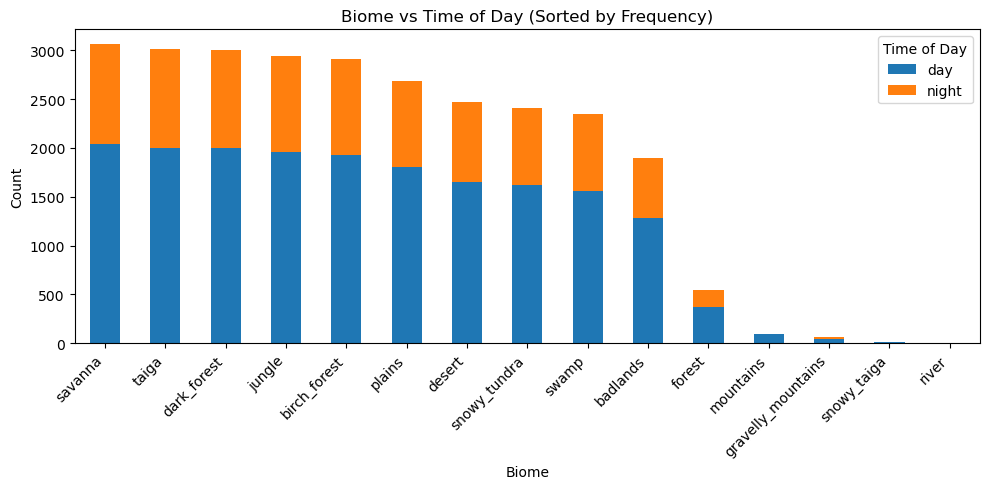

In [14]:
# distribution of biome types across time of day
ct = pd.crosstab(df["biome"], df["time_description"])
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index] # sort by total frequency

ct.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("Biome vs Time of Day (Sorted by Frequency)")
plt.xlabel("Biome")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Time of Day")
plt.tight_layout()
plt.show()

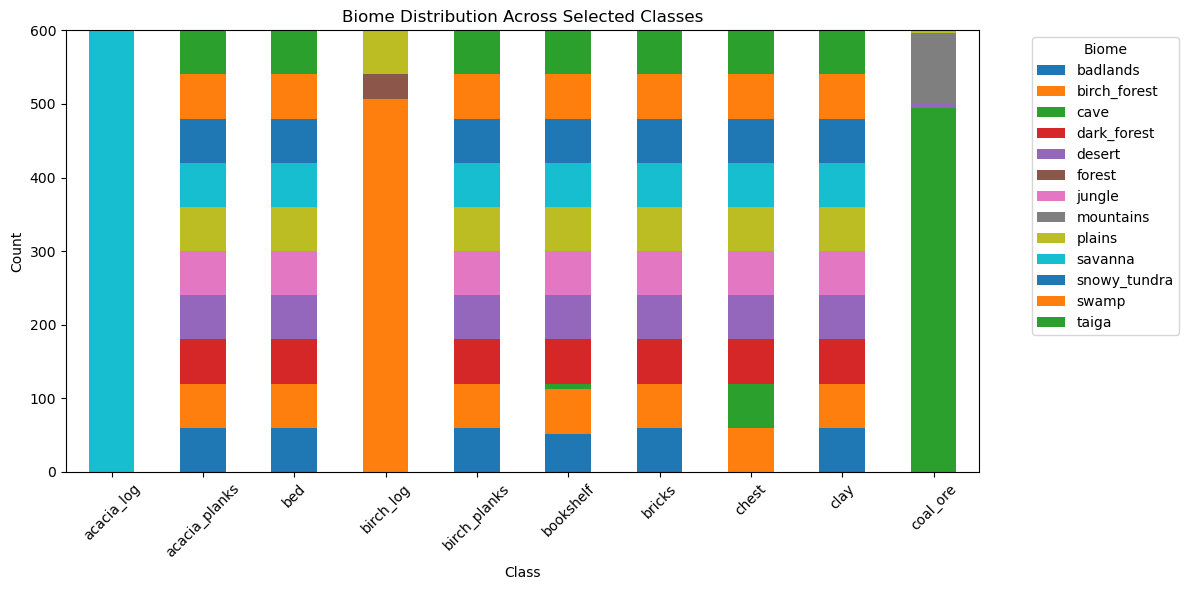

In [15]:
# plot biome distribution across classes (only first 10 classes for readability)
subset_classes = df["class_name"].unique()[:10]  # pick 10 classes

subset_df = df[df["class_name"].isin(subset_classes)]

ct = pd.crosstab(subset_df["class_name"], subset_df["biome"])
ct.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Biome Distribution Across Selected Classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Biome", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [ ]:
# split the train/val set from original train set (90% train, 10% val)
random.seed(42)  # for reproducibility
train_ds = train_ds_s  # avoid modifying original dataset
train_size = int(0.9 * len(train_ds_s))
val_size = len(train_ds_s) - train_size
train_ds, val_ds = random_split(train_ds, [train_size, val_size])
test_ds = test_ds_s  # test set remains unchanged

print(f"Train set size: {len(train_ds)}")
print(f"Val set size: {len(val_ds)}")
print(f"Test set size: {len(test_ds)}")

Train set size: 29160
Val set size: 3240
Test set size: 3600


In [19]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

transform_basic = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# load the full original train folder with basic transform
full_train_dataset = datasets.ImageFolder(
    os.path.join(SMALL_DIR, "train"),
    transform=transform_basic
)

# use the indices from your split
train_dataset_raw = Subset(full_train_dataset, train_ds.indices)

loader = DataLoader(train_dataset_raw, batch_size=64, shuffle=False, num_workers=2)

mean = torch.zeros(3)
std = torch.zeros(3)
total_images = 0

for images, _ in loader:
    batch_size = images.size(0)
    images = images.view(batch_size, 3, -1)

    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total_images += batch_size

mean /= total_images
std /= total_images

print("Mean:", mean)
print("Std:", std)

Mean: tensor([0.2109, 0.2025, 0.1632])
Std: tensor([0.0983, 0.0965, 0.1143])


In [20]:
# use mean and std to build transforms with normalization
mean = mean.tolist()
std = std.tolist()

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [21]:
import matplotlib.pyplot as plt

def show_augmentations(image, transform, n=4):
    fig, axes = plt.subplots(1, n+1, figsize=(15,4))
    
    # original
    axes[0].imshow(image)
    axes[0].set_title("Original")
    axes[0].axis("off")
    
    for i in range(n):
        aug_img = transform(image)
        aug_img = aug_img.permute(1,2,0).numpy()
        
        # unnormalize for visualization
        aug_img = (aug_img - aug_img.min()) / (aug_img.max() - aug_img.min())
        
        axes[i+1].imshow(aug_img)
        axes[i+1].set_title("Augmented")
        axes[i+1].axis("off")
    
    plt.show()

## Archive code

In [ ]:
# # Large dataset
# print("\n" + "─"*50)
# print(" LARGE DATASET")
# print("─"*50)
# train_loader_l, train_ds_l, test_loader_l, test_ds_l = load_data(LARGE_DIR)
# print_dataset_statistics(train_ds_l, test_ds_l, label='LARGE')
# plot_class_distribution(train_ds_l, test_ds_l,  title_prefix='Large Dataset')
# show_class_samples(train_ds_l, samples_per_class=4, title_prefix='Large Dataset')

In [ ]:
# import random

# def show_resolution_comparison(small_root, large_root, n_samples=4, split='train'):
#     """
#     Pick n_samples random classes, find the matching image in both datasets,
#     and display them side by side with resolution annotations.
    
#     Args:
#         small_root : Path to MiDaS-60_small (contains train/ and test/)
#         large_root : Path to MiDaS-60_large (contains train/ and test/)
#         n_samples  : Number of classes to sample
#         split      : 'train' or 'test'
#     """
#     small_split = os.path.join(small_root, split)
#     large_split = os.path.join(large_root, split)

#     # Find classes present in both datasets
#     small_classes = set(os.listdir(small_split))
#     large_classes = set(os.listdir(large_split))
#     common_classes = sorted(small_classes & large_classes)

#     assert len(common_classes) >= n_samples, \
#         f"Only {len(common_classes)} common classes found, requested {n_samples}"

#     sampled_classes = random.sample(common_classes, n_samples)

#     fig, axes = plt.subplots(
#         n_samples, 2,
#         figsize=(7, n_samples * 3.2)
#     )
#     fig.suptitle(
#         'Small vs Large Dataset — Same Image, Different Resolution',
#         fontsize=13, y=1.01, fontweight='bold'
#     )

#     # Column headers
#     axes[0, 0].set_title('Small', fontsize=11, fontweight='bold', color='#4C9BE8', pad=8)
#     axes[0, 1].set_title('Large', fontsize=11, fontweight='bold', color='#F28C38', pad=8)

#     for row, cls in enumerate(sampled_classes):
#         small_cls_dir = os.path.join(small_split, cls)
#         large_cls_dir = os.path.join(large_split, cls)

#         # Find a filename present in both class folders
#         small_files = set(os.listdir(small_cls_dir))
#         large_files = set(os.listdir(large_cls_dir))
#         common_files = sorted(small_files & large_files)

#         if common_files:
#             fname = common_files[0]                         # matched filename
#         else:
#             # Fallback: just pick the first file from each independently
#             fname = None

#         small_img_path = os.path.join(small_cls_dir, fname if fname else sorted(small_files)[0])
#         large_img_path = os.path.join(large_cls_dir, fname if fname else sorted(large_files)[0])

#         small_img = Image.open(small_img_path).convert('RGB')
#         large_img = Image.open(large_img_path).convert('RGB')

#         sw, sh = small_img.size
#         lw, lh = large_img.size

#         for col, (img, res, color, matched) in enumerate([
#             (small_img, f'{sw} × {sh} px', '#4C9BE8', fname is not None),
#             (large_img, f'{lw} × {lh} px', '#F28C38', fname is not None),
#         ]):
#             ax = axes[row, col]
#             ax.imshow(img)
#             ax.set_xticks([]); ax.set_yticks([])

#             # Resolution badge in bottom-right corner
#             ax.text(
#                 0.98, 0.03, res,
#                 transform=ax.transAxes,
#                 ha='right', va='bottom',
#                 fontsize=8.5, fontweight='bold', color='white',
#                 bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.75, edgecolor='none')
#             )

#             # Class label on the left of the first column
#             if col == 0:
#                 ax.set_ylabel(
#                     cls.replace('_', '\n'),
#                     fontsize=8.5, rotation=0,
#                     labelpad=55, va='center'
#                 )

#         # Mark whether this is a filename-matched pair
#         match_note = '✓ same filename' if fname else '~ same class, diff filename'
#         axes[row, 1].text(
#             0.98, 0.97, match_note,
#             transform=axes[row, 1].transAxes,
#             ha='right', va='top',
#             fontsize=7, color='white',
#             bbox=dict(boxstyle='round,pad=0.25',
#                       facecolor='#2ecc71' if fname else '#e67e22',
#                       alpha=0.75, edgecolor='none')
#         )

#     plt.tight_layout()
#     plt.show()


# # ── Run ───────────────────────────────────────────────────────────────────────
# SMALL_PATH = 'path/to/MiDaS-60_small'
# LARGE_PATH = 'path/to/MiDaS-60_large'

# show_resolution_comparison(SMALL_PATH, LARGE_PATH, n_samples=4, split='train')